In [ ]:
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from top2vec import Top2Vec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import torch

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})

print("All imports OK")

All imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
EN_DIR  = Path("/content/drive/MyDrive/medical_protocols/en_aux_v1_fixed")
RU_DIR  = Path("/content/drive/MyDrive/medical_protocols/gold_standard_md")
OUT_DIR = Path("/content/drive/MyDrive/medical_protocols/top2vec")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_CHARS      = 200   # must match EN + RU embedding pipelines
TOP_K_ALIGN    = 3     # top-k EN topics per RU topic in alignment table
MODEL_NAME     = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

print(f"EN_DIR : {EN_DIR}")
print(f"RU_DIR : {RU_DIR}")
print(f"OUT_DIR: {OUT_DIR}")


EN_DIR : /content/drive/MyDrive/medical_protocols/en_aux_v1_fixed
RU_DIR : /content/drive/MyDrive/medical_protocols/gold_standard_md
OUT_DIR: /content/drive/MyDrive/medical_protocols/top2vec


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model = SentenceTransformer(MODEL_NAME, device=device)
print(f"Embedding model loaded on {device}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded on cuda


In [ ]:
def split_markdown_sections(md_text: str, min_chars: int = 200):
    """
    Split markdown by ## headers.
    Returns list of (title, body) tuples where len(body) >= min_chars.
    """
    md_text = md_text.replace("\r\n", "\n").strip()
    parts = re.split(r"(?=^##\s+)", md_text, flags=re.M)
    out = []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        lines = part.splitlines()
        if lines and lines[0].startswith("##"):
            title = lines[0].lstrip("#").strip()
            body  = "\n".join(lines[1:]).strip()
        else:
            title = "NO_HEADER"
            body  = part
        if len(body) >= min_chars:
            out.append((title, body))
    return out


def build_docs(folder: Path, prefix: str, min_chars: int = 200):
    """Read all .md files and build flat section lists for Top2Vec."""
    docs, doc_ids, meta_rows = [], [], []

    files = sorted(folder.glob("*.md"))
    for fp in tqdm(files, desc=f"Building docs [{prefix}]"):
        text = fp.read_text(encoding="utf-8", errors="ignore")
        sections = split_markdown_sections(text, min_chars=min_chars)
        for i, (title, body) in enumerate(sections):
            did = f"{prefix}:{fp.name}::sec={i}"
            docs.append(body)
            doc_ids.append(did)
            meta_rows.append({
                "doc_id": did,
                "file": fp.name,
                "section_id": i,
                "section_title": title,
                "chars": len(body),
            })

    meta = pd.DataFrame(meta_rows)
    return docs, doc_ids, meta

In [ ]:
en_docs, en_doc_ids, en_meta = build_docs(EN_DIR, "EN", min_chars=MIN_CHARS)
ru_docs, ru_doc_ids, ru_meta = build_docs(RU_DIR, "RU", min_chars=MIN_CHARS)

print(f"EN sections: {len(en_docs)}")
print(f"RU sections: {len(ru_docs)}")

en_meta.to_csv(OUT_DIR / "en_sections_meta.csv", index=False)
ru_meta.to_csv(OUT_DIR / "ru_sections_meta.csv", index=False)
print(f"Saved section metadata to: {OUT_DIR}")

Building docs [RU]: 100%|██████████| 84/84 [00:00<00:00, 290.49it/s]


EN sections: 2029
RU sections: 2490
Saved section metadata to: /content/drive/MyDrive/medical_protocols/top2vec


In [ ]:
def encode_fn(texts):
    """Wrapper so Top2Vec uses our multilingual sentence-transformer."""
    return embedding_model.encode(texts, show_progress_bar=False)


def run_top2vec(lang: str, docs, doc_ids, out_dir: Path):
    """
    Train Top2Vec, save topics CSV, doc→topic CSV, and topic vectors .npy.
    Returns (model, df_topics, df_doc_topics, topic_vectors).
    """
    print(f"\nTraining Top2Vec [{lang}] on {len(docs)} sections...")
    t2v = Top2Vec(
        documents=docs,
        document_ids=doc_ids,
        embedding_model=encode_fn,
        speed="learn",
    )

    n_topics = t2v.get_num_topics()
    print(f"  Topics discovered: {n_topics}")

    topic_words, _, topic_nums = t2v.get_topics()
    topic_sizes, topic_ids = t2v.get_topic_sizes()
    size_map = {int(t): int(s) for t, s in zip(topic_ids, topic_sizes)}

    topic_rows = []
    for t in topic_nums:
        t = int(t)
        topic_rows.append({
            "lang": lang,
            "topic_id": t,
            "size": size_map.get(t, 0),
            "keywords": ", ".join(topic_words[t][:15]),
        })
    df_topics = pd.DataFrame(topic_rows).sort_values("size", ascending=False)
    df_topics.to_csv(out_dir / f"top2vec_topics_{lang}.csv", index=False)

    _result = t2v.get_documents_topics(doc_ids)
    doc_topic_ids, doc_topic_scores = _result[0], _result[1]
    df_dt = pd.DataFrame({
        "doc_id": doc_ids,
        "topic_id": [int(x) for x in doc_topic_ids],
        "topic_score": doc_topic_scores,
    })
    df_dt.to_csv(out_dir / f"top2vec_doc_topics_{lang}.csv", index=False)

    topic_vecs = t2v.topic_vectors  # (n_topics, dim)
    np.save(out_dir / f"top2vec_topic_vectors_{lang}.npy", topic_vecs)

    print(f"  Saved: topics, doc_topics, topic_vectors [{lang}]")
    return t2v, df_topics, df_dt, topic_vecs


en_model, en_topics, en_doc_topics, en_topic_vecs = run_top2vec("EN", en_docs, en_doc_ids, OUT_DIR)
ru_model, ru_topics, ru_doc_topics, ru_topic_vecs = run_top2vec("RU", ru_docs, ru_doc_ids, OUT_DIR)

2026-03-01 13:36:29,888 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training



Training Top2Vec [EN] on 2029 sections...


2026-03-01 13:36:31,119 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-03-01 13:36:38,102 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-03-01 13:36:45,911 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-03-01 13:36:45,982 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics
2026-03-01 13:36:46,100 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training


  Topics discovered: 10
  Saved: topics, doc_topics, topic_vectors [EN]

Training Top2Vec [RU] on 2490 sections...


2026-03-01 13:36:47,366 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-03-01 13:36:55,923 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-03-01 13:37:07,033 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-03-01 13:37:07,102 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


  Topics discovered: 28
  Saved: topics, doc_topics, topic_vectors [RU]


In [ ]:
S = cosine_similarity(ru_topic_vecs, en_topic_vecs)

rows = []
for ru_t in range(S.shape[0]):
    best_en = np.argsort(-S[ru_t])[:TOP_K_ALIGN]
    ru_kw = ru_topics.loc[ru_topics["topic_id"] == ru_t, "keywords"].values
    for rank, en_t in enumerate(best_en, start=1):
        en_kw = en_topics.loc[en_topics["topic_id"] == en_t, "keywords"].values
        rows.append({
            "ru_topic":   int(ru_t),
            "en_topic":   int(en_t),
            "rank":       rank,
            "cosine_sim": float(S[ru_t, en_t]),
            "ru_keywords": ru_kw[0] if len(ru_kw) else "",
            "en_keywords": en_kw[0] if len(en_kw) else "",
        })

df_align = pd.DataFrame(rows).sort_values(["ru_topic", "rank"])
out_align = OUT_DIR / "top2vec_ru_en_topic_alignment.csv"
df_align.to_csv(out_align, index=False)
print(f"Saved: {out_align}")

rank1 = df_align[df_align["rank"] == 1]["cosine_sim"]
print(f"\nRank-1 cross-lingual cosine similarity:")
print(f"  Mean  : {rank1.mean():.4f}")
print(f"  Median: {rank1.median():.4f}")
print(f"  Min   : {rank1.min():.4f}")
print(f"  Max   : {rank1.max():.4f}")
print(f"  Topics with sim > 0.90: {(rank1 > 0.90).sum()} / {len(rank1)}")

display(df_align.head(15))

Saved: /content/drive/MyDrive/medical_protocols/top2vec/top2vec_ru_en_topic_alignment.csv

Rank-1 cross-lingual cosine similarity:
  Mean  : 0.7613
  Median: 0.7540
  Min   : 0.4738
  Max   : 0.9436
  Topics with sim > 0.90: 1 / 28


,ru_topic,en_topic,rank,cosine_sim,ru_keywords,en_keywords
0,0,0,1,0.887399,"беременные, беременности, беременных, беременн...","intrauterine, cesarean, preeclampsia, obstetri..."
1,0,2,2,0.728965,"беременные, беременности, беременных, беременн...","ovulation, ovaries, ovarian, ovary, uterus, re..."
2,0,1,3,0.709230,"беременные, беременности, беременных, беременн...","intrauterine, diagnosis, diagnosing, cesarean,..."
3,1,1,1,0.943627,"диагностические, диагностики, диагноза, диагно...","intrauterine, diagnosis, diagnosing, cesarean,..."
4,1,4,2,0.794060,"диагностические, диагностики, диагноза, диагно...","intrauterine, diagnosis, diagnosing, diagnosti..."
5,1,0,3,0.774903,"диагностические, диагностики, диагноза, диагно...","intrauterine, cesarean, preeclampsia, obstetri..."
6,2,9,1,0.738285,"клинически, клинического, клинические, клиниче...","contraindicated, clinically, complications, su..."
7,2,0,2,0.731089,"клинически, клинического, клинические, клиниче...","intrauterine, cesarean, preeclampsia, obstetri..."
8,2,3,3,0.674059,"клинически, клинического, клинические, клиниче...","surgical, surgery, postoperative, laparoscopic..."
9,3,0,1,0.772713,"симптомов, симптомы, менструального, кровотече...","intrauterine, cesarean, preeclampsia, obstetri..."


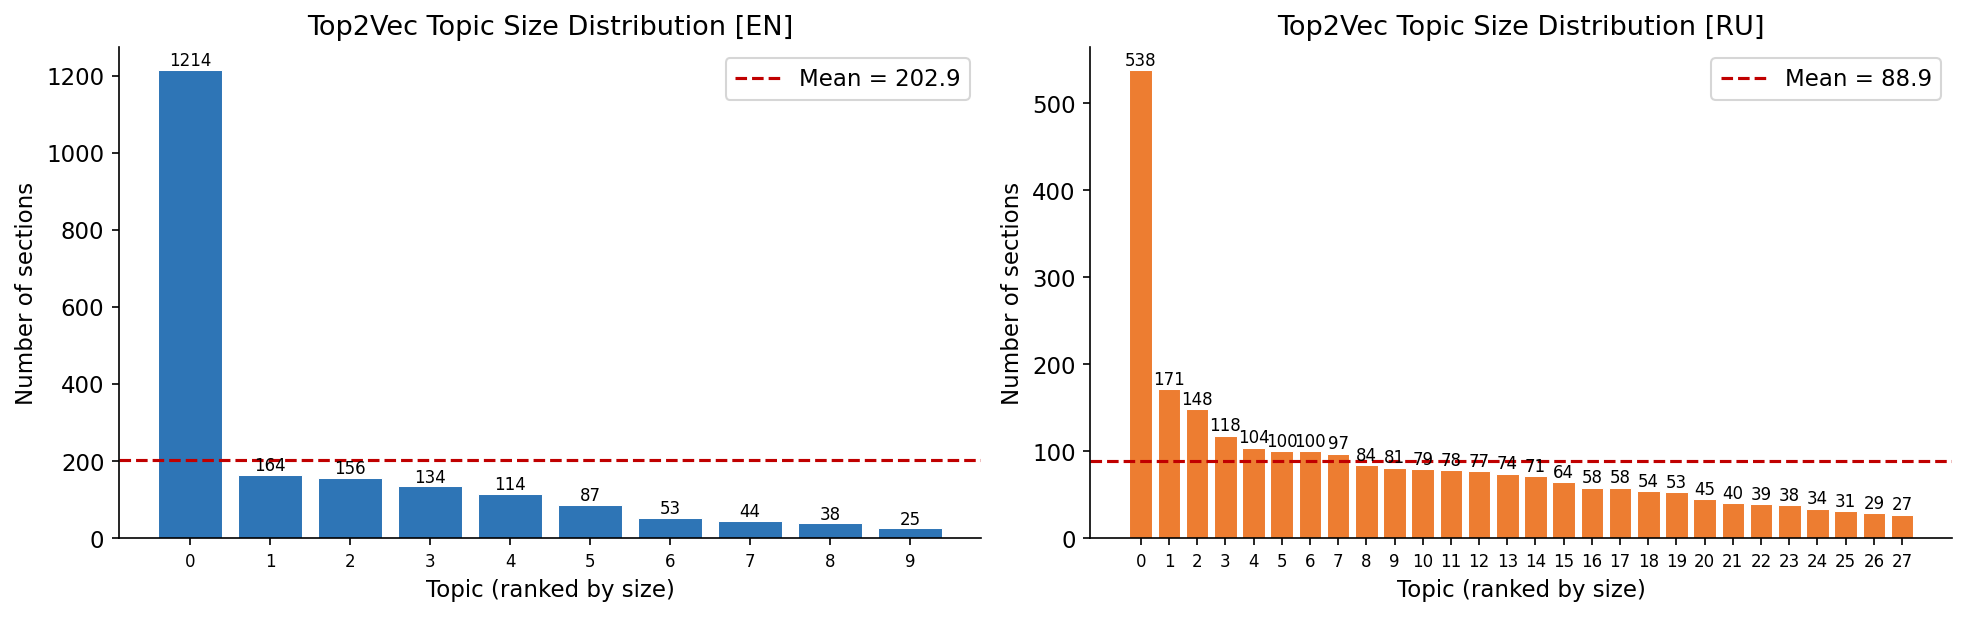

EN topics: 10  |  RU topics: 28


In [ ]:
# ── Topic size distribution (EN + RU side by side) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df_t, lang, color in [
    (axes[0], en_topics, "EN", "#2E75B6"),
    (axes[1], ru_topics, "RU", "#ED7D31"),
]:
    df_sorted = df_t.sort_values("size", ascending=False).reset_index(drop=True)
    bars = ax.bar(range(len(df_sorted)), df_sorted["size"],
                  color=color, edgecolor="white", linewidth=0.5)
    ax.axhline(df_sorted["size"].mean(), color="#C00000", linewidth=1.5,
               linestyle="--", label=f'Mean = {df_sorted["size"].mean():.1f}')
    for bar, val in zip(bars, df_sorted["size"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha="center", va="bottom", fontsize=8)
    ax.set_title(f"Top2Vec Topic Size Distribution [{lang}]")
    ax.set_xlabel("Topic (ranked by size)")
    ax.set_ylabel("Number of sections")
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted["topic_id"].astype(str), fontsize=8)
    ax.legend()

fig.savefig(OUT_DIR / "fig_topic_size_distribution.png", bbox_inches="tight")
plt.show()

print(f"EN topics: {len(en_topics)}  |  RU topics: {len(ru_topics)}")

In [ ]:
# ── Top keywords per topic table ─────────────────────────────────────────
print("=" * 60)
print("EN TOPICS — top keywords")
print("=" * 60)
for _, row in en_topics.sort_values("topic_id").iterrows():
    print(f'  Topic {int(row["topic_id"]):>2} (n={int(row["size"]):>3}): {row["keywords"][:80]}')

print()
print("=" * 60)
print("RU TOPICS — top keywords")
print("=" * 60)
for _, row in ru_topics.sort_values("topic_id").iterrows():
    print(f'  Topic {int(row["topic_id"]):>2} (n={int(row["size"]):>3}): {row["keywords"][:80]}')

EN TOPICS — top keywords
  Topic  0 (n=1214): intrauterine, cesarean, preeclampsia, obstetric, clinically, clinical, gynecolog
  Topic  1 (n=164): intrauterine, diagnosis, diagnosing, cesarean, obstetric, gynecological, obstetr
  Topic  2 (n=156): ovulation, ovaries, ovarian, ovary, uterus, reproductive, intrauterine, infertil
  Topic  3 (n=134): surgical, surgery, postoperative, laparoscopic, laparoscopy, nephrectomy, fallop
  Topic  4 (n=114): intrauterine, diagnosis, diagnosing, diagnostic, clinical, diagnosed, obstetric,
  Topic  5 (n= 87): clinical, intrauterine, clinically, translation, cesarean, diagnosis, obstetric,
  Topic  6 (n= 53): protocol, clinical, clinically, diagnosing, procedure, diagnosis, diagnostic, pa
  Topic  7 (n= 44): examinations, clinical, clinically, examination, patients, prescribed, tests, te
  Topic  8 (n= 38): clinically, clinical, diagnosing, assessment, assess, diagnosis, diagnostic, ana
  Topic  9 (n= 25): contraindicated, clinically, complications, s

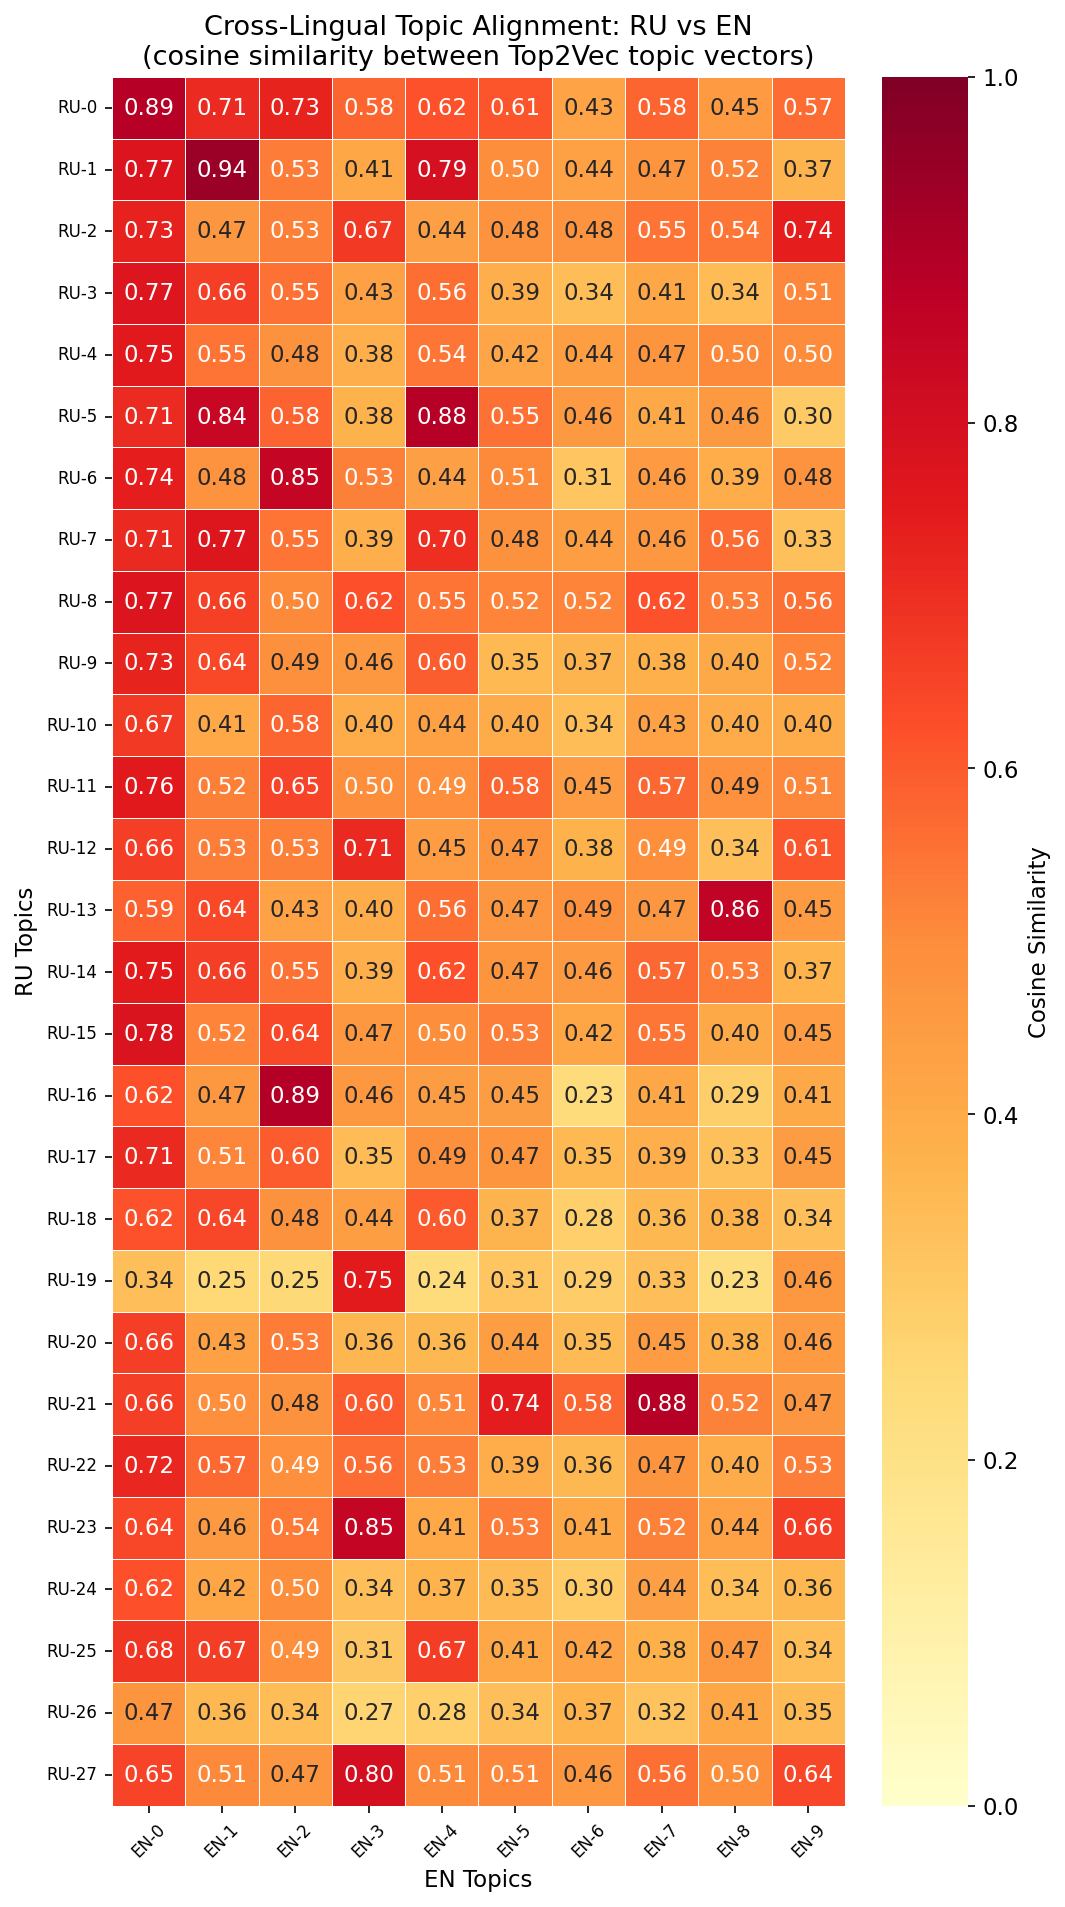

Rank-1 cross-lingual cosine similarity:
  Mean  : 0.7613
  Median: 0.7540
  Min   : 0.4738
  Max   : 0.9436
  Topics with sim > 0.90: 1 / 28


In [ ]:
# ── Cross-lingual alignment heatmap ──────────────────────────────────────
S = cosine_similarity(ru_topic_vecs, en_topic_vecs)

fig, ax = plt.subplots(figsize=(max(7, len(en_topic_vecs)*0.55),
                                max(5, len(ru_topic_vecs)*0.45)))
sns.heatmap(
    S, annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=0, vmax=1, linewidths=0.4, ax=ax,
    xticklabels=[f"EN-{i}" for i in range(S.shape[1])],
    yticklabels=[f"RU-{i}" for i in range(S.shape[0])],
    cbar_kws={"label": "Cosine Similarity"},
)
ax.set_title(
    "Cross-Lingual Topic Alignment: RU vs EN\n"
    "(cosine similarity between Top2Vec topic vectors)"
)
ax.set_xlabel("EN Topics")
ax.set_ylabel("RU Topics")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
fig.savefig(OUT_DIR / "fig_cross_lingual_alignment_heatmap.png", bbox_inches="tight")
plt.show()

# ── Rank-1 summary stats ─────────────────────────────────────────────────
rank1_sims = S.max(axis=1)   # best EN match for each RU topic
print(f"Rank-1 cross-lingual cosine similarity:")
print(f"  Mean  : {rank1_sims.mean():.4f}")
print(f"  Median: {np.median(rank1_sims):.4f}")
print(f"  Min   : {rank1_sims.min():.4f}")
print(f"  Max   : {rank1_sims.max():.4f}")
print(f"  Topics with sim > 0.90: {(rank1_sims > 0.90).sum()} / {len(rank1_sims)}")

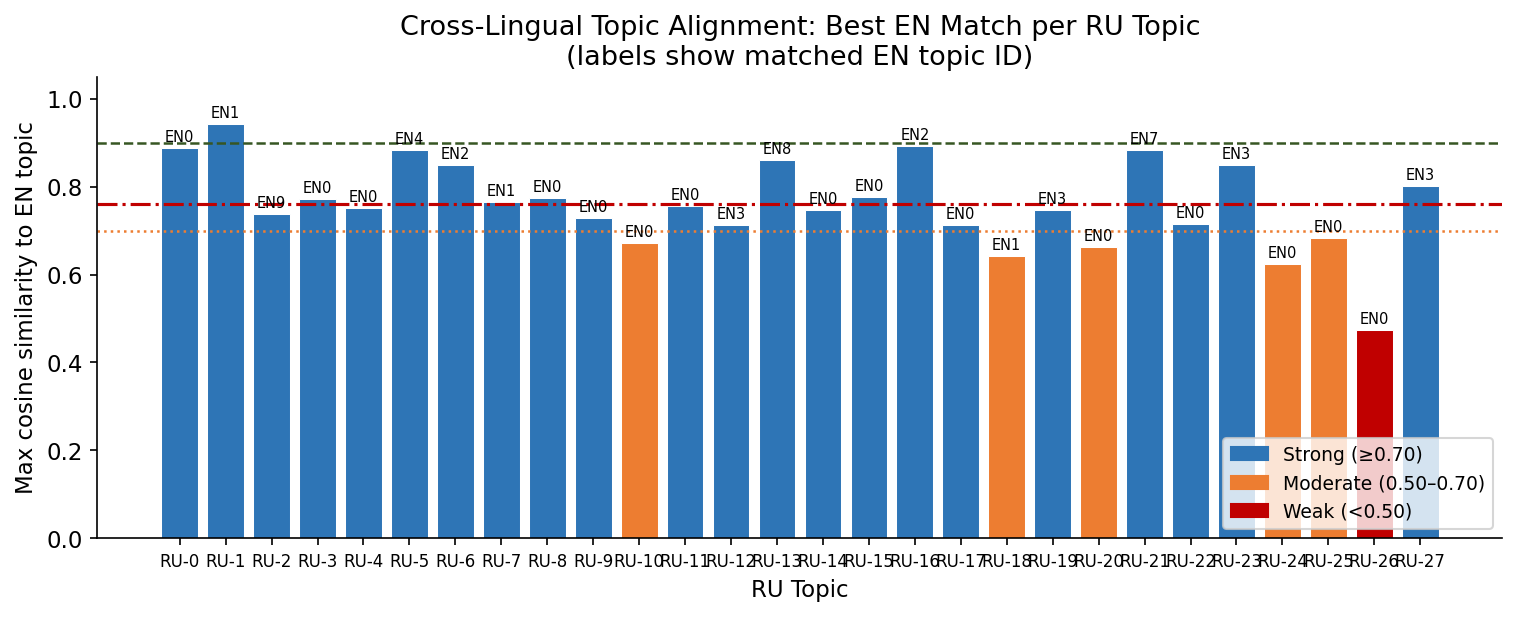

In [ ]:
# ── Rank-1 alignment bar chart ───────────────────────────────────────────
rank1_sims = S.max(axis=1)
best_en    = S.argmax(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2E75B6" if s >= 0.70 else "#ED7D31" if s >= 0.50 else "#C00000"
          for s in rank1_sims]
bars = ax.bar(range(len(rank1_sims)), rank1_sims, color=colors,
              edgecolor="white", linewidth=0.5)
ax.axhline(0.90, color="#375623", linewidth=1.2, linestyle="--",
           label="Strong alignment (0.90)")
ax.axhline(0.70, color="#ED7D31", linewidth=1.2, linestyle=":",
           label="Moderate alignment (0.70)")
ax.axhline(rank1_sims.mean(), color="#C00000", linewidth=1.5, linestyle="-.",
           label=f"Mean = {rank1_sims.mean():.3f}")
for i, (bar, sim, en_t) in enumerate(zip(bars, rank1_sims, best_en)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"EN{en_t}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(range(len(rank1_sims)))
ax.set_xticklabels([f"RU-{i}" for i in range(len(rank1_sims))], fontsize=8)
ax.set_xlabel("RU Topic")
ax.set_ylabel("Max cosine similarity to EN topic")
ax.set_title("Cross-Lingual Topic Alignment: Best EN Match per RU Topic\n"
             "(labels show matched EN topic ID)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

legend_patches = [
    mpatches.Patch(color="#2E75B6", label="Strong (≥0.70)"),
    mpatches.Patch(color="#ED7D31", label="Moderate (0.50–0.70)"),
    mpatches.Patch(color="#C00000", label="Weak (<0.50)"),
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][3:],
          fontsize=9, loc="lower right")
fig.savefig(OUT_DIR / "fig_rank1_alignment_bar.png", bbox_inches="tight")
plt.show()

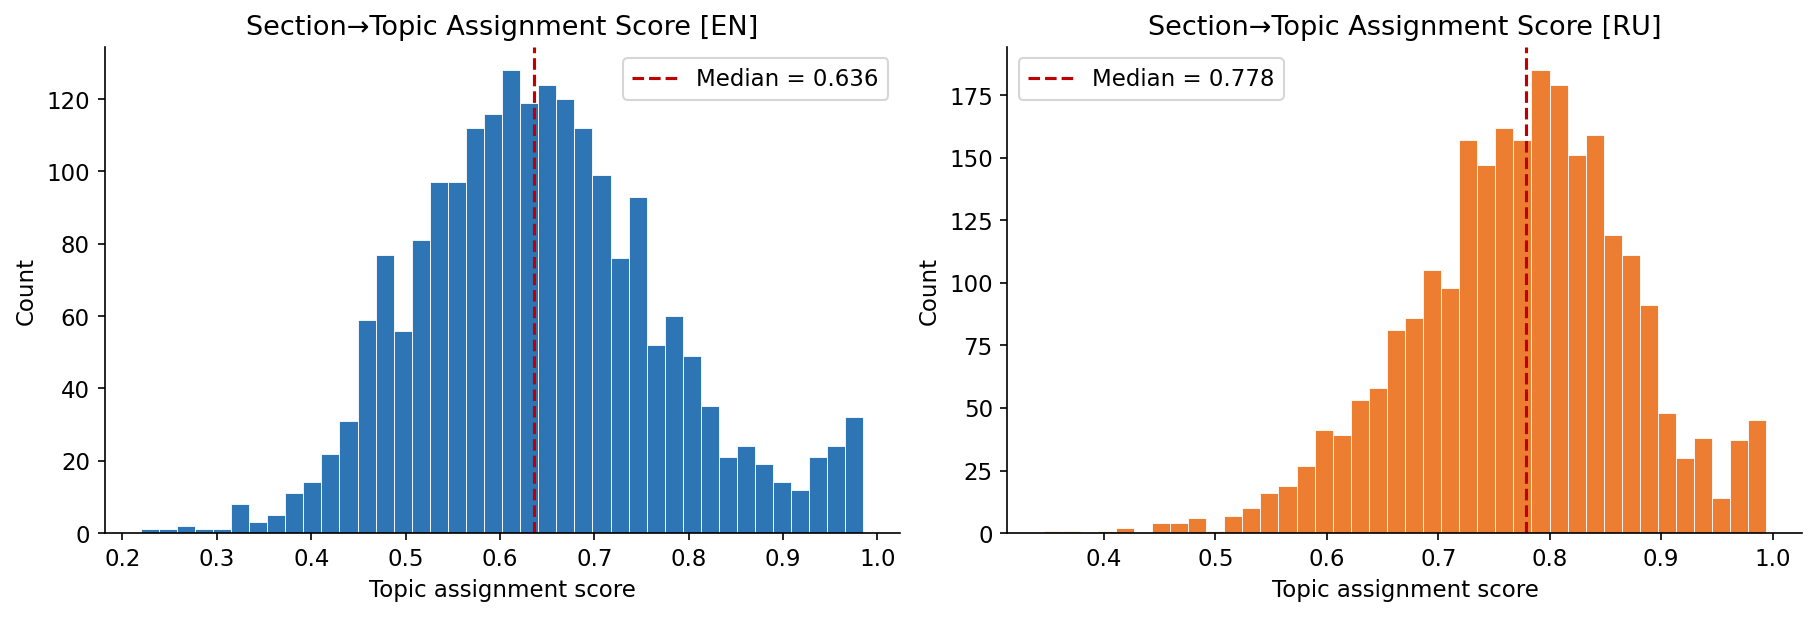

In [ ]:
# ── Document-topic score distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df_dt, lang, color in [
    (axes[0], en_doc_topics, "EN", "#2E75B6"),
    (axes[1], ru_doc_topics, "RU", "#ED7D31"),
]:
    ax.hist(df_dt["topic_score"], bins=40, color=color,
            edgecolor="white", linewidth=0.4)
    ax.axvline(df_dt["topic_score"].median(), color="#C00000",
               linewidth=1.5, linestyle="--",
               label=f'Median = {df_dt["topic_score"].median():.3f}')
    ax.set_title(f"Section→Topic Assignment Score [{lang}]")
    ax.set_xlabel("Topic assignment score")
    ax.set_ylabel("Count")
    ax.legend()

fig.savefig(OUT_DIR / "fig_doc_topic_score_distribution.png", bbox_inches="tight")
plt.show()

In [ ]:
# ── Validation summary ───────────────────────────────────────────────────
rank1_sims = S.max(axis=1)

summary = {
    "en_n_topics":            int(len(en_topics)),
    "ru_n_topics":            int(len(ru_topics)),
    "en_sections":            int(len(en_doc_topics)),
    "ru_sections":            int(len(ru_doc_topics)),
    "rank1_cosine_mean":      round(float(rank1_sims.mean()), 4),
    "rank1_cosine_median":    round(float(np.median(rank1_sims)), 4),
    "rank1_cosine_min":       round(float(rank1_sims.min()), 4),
    "rank1_cosine_max":       round(float(rank1_sims.max()), 4),
    "topics_sim_above_0_90":  int((rank1_sims > 0.90).sum()),
    "topics_sim_above_0_70":  int((rank1_sims > 0.70).sum()),
    "embedding_model":        MODEL_NAME,
    "min_chars":              int(MIN_CHARS),
}

out_json = OUT_DIR / "top2vec_summary.json"
out_json.write_text(__import__("json").dumps(summary, indent=2), encoding="utf-8")

print("\n" + "="*55)
print("  TOP2VEC CROSS-LINGUAL ALIGNMENT — SUMMARY")
print("="*55)
for k, v in summary.items():
    print(f"  {k:<35} {v}")
print("="*55)
print(f"\nAll outputs saved to: {OUT_DIR}")
print("\nFiles written:")
for f in sorted(OUT_DIR.glob("*.csv")) + sorted(OUT_DIR.glob("*.npy")) + \
         sorted(OUT_DIR.glob("*.json")) + sorted(OUT_DIR.glob("*.png")):
    print(f"  {f.name}")


  TOP2VEC CROSS-LINGUAL ALIGNMENT — SUMMARY
  en_n_topics                         10
  ru_n_topics                         28
  en_sections                         2029
  ru_sections                         2490
  rank1_cosine_mean                   0.7613
  rank1_cosine_median                 0.754
  rank1_cosine_min                    0.4738
  rank1_cosine_max                    0.9436
  topics_sim_above_0_90               1
  topics_sim_above_0_70               22
  embedding_model                     sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  min_chars                           200

All outputs saved to: /content/drive/MyDrive/medical_protocols/top2vec

Files written:
  en_sections_meta.csv
  ru_sections_meta.csv
  top2vec_doc_topics_EN.csv
  top2vec_doc_topics_RU.csv
  top2vec_ru_en_topic_alignment.csv
  top2vec_topics_EN.csv
  top2vec_topics_RU.csv
  top2vec_topic_vectors_EN.npy
  top2vec_topic_vectors_RU.npy
  top2vec_summary.json
  fig_cross_lingual_alignmen